In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline


# reading the qc file
qc_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\QC_msmetrix.xlsx",
    sheet_name=0,
    header=12
)

print(qc_data.head())



   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041                69053                62942  ...   
3               296333

In [37]:
qc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   ID Names               589 non-null    object 
 6   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 7   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 8   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 9   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 10  s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 11  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 12  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 13  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 14  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 15  s10 S9

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler



input_path  = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\samples day1-10.xlsx"
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\all_real_samples_combined.xlsx"

# Reading without headers, just to find the header row
df_raw = pd.read_excel(input_path, header=None)

# getting the data columns
header_row = df_raw[df_raw.iloc[:,0].astype(str).str.strip() == "Peak"].index[0]

# Re-reading using that row as the header
potato_data = pd.read_excel(input_path, header=header_row)

# Dropping any completely empty columns
data = potato_data.dropna(axis=1, how="all")

#  Seeing the dataframe
print(data.shape)
print(data.columns.tolist())
print(data.head())

(633, 175)
['Peak', 'tR1', 'tR2', 'tR', 'm/z', 'ID Names', 's1 S96_44_B1_D1_T1', 's1 S96_44_B1_D1_T2', 's3 S96_9_B1_D1_T1', 's4 S96_28_B1_D1_T1', 's5 S96_92_B1_D1_T1', 's6 S96_21_B1_D1_T1', 's7 S96_53_B1_D1_T1', 's8 S96_55_B1_D1_T1', 's9 S96_44_B1_D1_T2', 's10 S96_55_B1_D1_T2', 's11 S96_21_B1_D1_T2', 's12 S96_14_B1_D1_T2', 's13 S96_7_B1_D1_T2', 's14 S96_83_B1_D1_T2', 's15 S96_92_B1_D1_T2', 's16 S96_28_B1_D1_T2', 's17 S96_83_B1_D1_T1', 's18 S96_7_B1_D1_T1', 's19 S96_53_B1_D1_T2', 's20 S96_42_B1_D2_T1', 's21 S96_56_B1_D2_T1', 's22 S96_6_B1_D2_T1', 's23 S96_38_B1_D2_T1', 's24 S96_48_B1_D2_T1', 's25 S96_76_B1_D2_T1', 's26 S96_10_B1_D2_T1', 's27 S96_38_B1_D2_T2', 's28 S96_76_B1_D2_T2', 's29 S96_48_B1_D2_T2', 's30 S96_6_B1_D2_T2', 's31 S96_10_B1_D2_T2', 's32 S96_42_B1_D2_T2', 's33 S96_79_B1_D2_T2', 's34 S96_86_B1_D2_T2', 's35 S96_56_B1_D2_T2', 's36 S96_79_B1_D2_T1', 's37 S96_86_B1_D2_T1', 's38 S96_87_B1_D3_T1', 's39 S96_16_B1_D3_T1', 's40 S96_81_B1_D3_T1', 's41 S96_81_B1_D3_T2', 's42 S96_50_

In [39]:
selected_data = data.iloc[:, :101]

In [40]:
selected_data.isnull().sum()

Peak                   0
tR1                    0
tR2                    0
tR                     0
m/z                    0
                      ..
s91 S96_12_B1_D5_T2    0
s92 S96_93_B1_D5_T2    0
s93 S96_15_B1_D6_T1    0
s94 S96_59_B1_D6_T1    0
s95 S96_25_B1_D6_T1    0
Length: 101, dtype: int64

In [41]:

# the pairwise differences to find the realation between retention times
diff_t_vs_1 = (selected_data['tR'] - selected_data['tR1']).abs()
diff_t_vs_2 = (selected_data['tR'] - selected_data['tR2']).abs()
diff_1_vs_2 = (selected_data['tR1'] - selected_data['tR2']).abs()
avg_t   = (selected_data['tR1'] + selected_data['tR2']) / 2
diff_avg_vs_t = (avg_t - selected_data['tR']).abs()

# printing to see the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    633.000000
mean       0.050104
std        0.035097
min        0.015000
25%        0.028000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR - tR2):
 count    633.000000
mean       0.050137
std        0.035105
min        0.015000
25%        0.027000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR1 - tR2):
 count    633.000000
mean       0.100242
std        0.070199
min        0.030000
25%        0.055000
50%        0.081000
75%        0.122000
max        0.738000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    6.330000e+02
mean     2.330174e-04
std      2.496198e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 



In [42]:

# Use tR_best instead of three tr
selected_data['tR_best'] = (selected_data['tR1'] + selected_data['tR2']) / 2

# Drop unnecessary columns
to_keep = [col for col in selected_data.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_sample_data = selected_data[to_keep]


# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_sample_data.columns)

cols = cleaned_sample_data.columns.tolist()

# Move 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_sample_data = cleaned_sample_data[cols]

#  The result
print(cleaned_sample_data.head())
# Save cleaned data with tR_best
cleaned_sample_data.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_sample_data.csv", index=False)


tR_best column saved: True
   Peak  tR_best  m/z                                           ID Names  \
0     1   1.9055   40    0.14%  || 40                                ...   
1     2   1.9625   44    1.40%  || 44   69  119                      ...   
2     3   1.9745   81    0.19%  || 81   96  169                      ...   
3     4   1.9955   42   12.80%  || 42  64  48  40  38  37  66  50  36...   
4     5   2.0415   41   10.30%  || 41  39  47  56  77  65  49  60    ...   

   s1 S96_44_B1_D1_T1  s1 S96_44_B1_D1_T2  s3 S96_9_B1_D1_T1  \
0               10596               20120              16056   
1               65017               61775              59978   
2               25722               21276              24105   
3             3396147             2999719            1910915   
4             3040149             3299916            1060080   

   s4 S96_28_B1_D1_T1  s5 S96_92_B1_D1_T1  s6 S96_21_B1_D1_T1  ...  \
0               19568               14816               21952

# Getting missing values

In [43]:
qc_data.isnull().sum()

Peak                     0
tR1                      0
tR2                      0
tR                       0
m/z                      0
ID Names                 0
s1 S96_QC1_B1_D1_T1      0
s2 S96_QC2_B1_D1_T1      0
s3 S96_QC3_B1_D1_T1      0
s4 S96_QC4_B1_D1_T1      0
s5 S96_QC1_B1_D2_T1      0
s6 S96_QC2_B1_D2_T1      0
s7 S96_QC3_B1_D2_T1      0
s8 S96_QC4_B1_D2_T1      0
s9 S96_QC1_B1_D3_T1      0
s10 S96_QC2_B1_D3_T1     0
s11 S96_QC3_B1_D3_T1     0
s12 S96_QC4_B1_D3_T1     0
s13 S96_QC2_B1_D4_T1     0
s14 S96_QC3_B1_D4_T1     0
s15 S96_QC4_B1_D4_T1     0
s16 S96_QC1_B1_D4_T1     0
s17 S96_QC1_B1_D5_T1     0
s18 S96_QC1_B1_D9_T1     0
s19 S96_QC2_B1_D5_T1     0
s20 S96_QC2_B1_D9_T1     0
s21 S96_QC3_B1_D5_T1     0
s22 S96_QC3_B1_D9_T1     0
s23 S96_QC4_B1_D5_T1     0
s24 S96_QC4_B1_D9_T1     0
s25 S96_QC1_B1_D10_T1    0
s26 S96_QC1_B1_D6_T1     0
s27 S96_QC1_B1_D7_T1     0
s28 S96_QC1_B1_D8_T1     0
s29 S96_QC3_B1_D10_T1    0
s30 S96_QC3_B1_D6_T1     0
s31 S96_QC3_B1_D7_T1     0
s

In [44]:

# Compute the pairwise differences 
diff_t_vs_1 = (qc_data['tR'] - qc_data['tR1']).abs()
diff_t_vs_2 = (qc_data['tR'] - qc_data['tR2']).abs()
diff_1_vs_2 = (qc_data['tR1'] - qc_data['tR2']).abs()
avg_t   = (qc_data['tR1'] + qc_data['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# Summarize
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [45]:
# put tr_best instead of other tr
qc_data['tR_best'] = (qc_data['tR1'] + qc_data['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()

# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]

# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z                                           ID Names  \
0     1   1.9065   40    0.15%  || 40                                ...   
1     2   1.9480   44    1.81%  || 44                                ...   
2     3   1.9640   81    0.14%  || 81   69  169  119                 ...   
3     4   1.9895   64    0.80%  || 64   48   61   66   96   37  131  ...   
4     5   2.0250   42    0.82%  || 42  41  40  39  38  50            ...   

   s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
0                44728                46928                46096   
1               354392               461936               609704   
2                75703                27041                69053   
3               238856               296333               363394   
4               207592               197912               201184   

   s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  s6 S96_QC2_B1_D2_T1  ...  \
0                44488            

# Peak detection for for qc data(compound identification)

In [46]:
# Define known alkanes with accurate retention time (tR) as we know these retention times
alkanes = [
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
]

# Convert to DataFrame
alkane_df = pd.DataFrame(alkanes)

# Set tighter tolerance for GC-MS matching
tr_tol = 0.2  # try 0.2 min window
mz_tol = 2    # use ±2 m/z

# Matching function
def match_alkane(row):
    for _, alk in alkane_df.iterrows():
        if abs(row['tR_best'] - alk['tR']) <= tr_tol:
            return alk['Compound']
    return 'Unknown'

# Apply cleaned qc
cleaned_qc['Matched_Compound'] = cleaned_qc.apply(match_alkane, axis=1)

# Show matches
matched = cleaned_qc[cleaned_qc['Matched_Compound'] != 'Unknown']
display(matched[['Peak', 'tR_best', 'm/z', 'Matched_Compound']])


,Peak,tR_best,m/z,Matched_Compound
67,68,5.1565,133,Octane
68,69,5.1760,149,Octane
69,70,5.3015,85,Octane
70,71,5.3270,43,Octane
71,72,5.4685,97,Octane
...,...,...,...,...
571,572,22.9020,85,Eicosane
572,573,22.9315,208,Eicosane
573,574,22.9695,57,Eicosane
574,575,22.9960,73,Eicosane


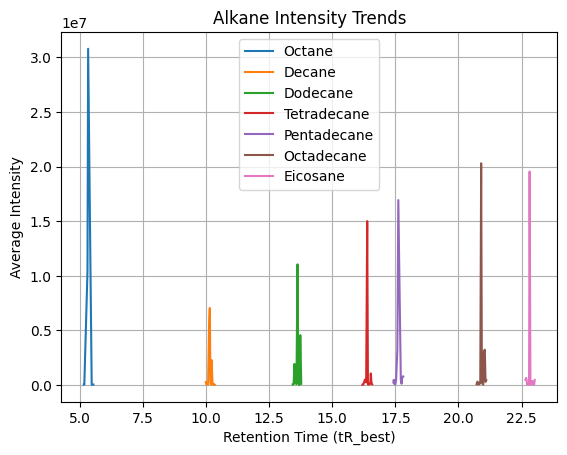

In [47]:
# Select only numeric intensity columns
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Plot mean intensity for each matched compound
for compound in cleaned_qc['Matched_Compound'].unique():
    if compound != 'Unknown':
        subset = cleaned_qc[cleaned_qc['Matched_Compound'] == compound]
        avg_intensity = subset[intensity_cols].mean(axis=1)
        plt.plot(subset['tR_best'], avg_intensity, label=compound)

plt.xlabel('Retention Time (tR_best)')
plt.ylabel('Average Intensity')
plt.title('Alkane Intensity Trends')
plt.legend()
plt.grid(True)
plt.show() 

# QC-Based Drift Correction Model (m/z = 57)

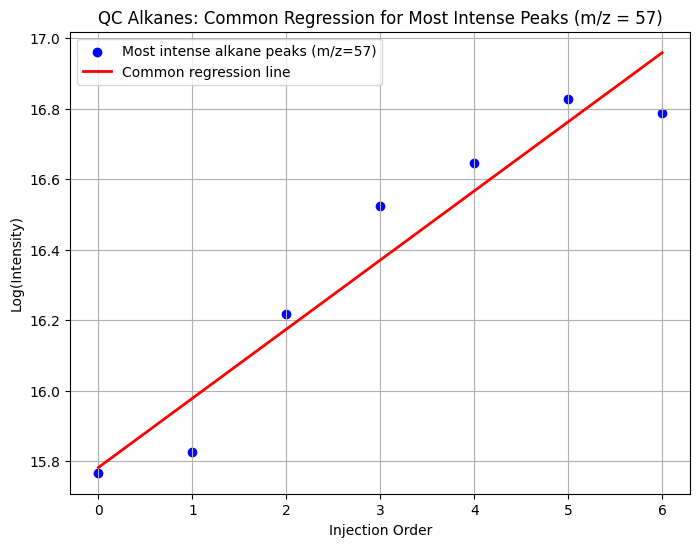

Common Regression Slope: 0.1961
Intercept: 15.7823


In [48]:
from sklearn.linear_model import LinearRegression

# Filter for alkane peaks with m/z = 57 
alkane_qc = cleaned_qc[cleaned_qc['m/z'] == 57].copy()

# Select numeric intensity columns
intensity_cols = alkane_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Compute total intensity per row 
alkane_qc['Total_Intensity'] = alkane_qc[intensity_cols].sum(axis=1)

# Select the most intense peak per alkane 
most_intense = alkane_qc.loc[alkane_qc.groupby('Matched_Compound')['Total_Intensity'].idxmax()]

# Log-transform intensity 
most_intense['Log_Intensity'] = np.log1p(most_intense[intensity_cols].mean(axis=1))

# Add injection order
most_intense = most_intense.sort_values(by='Injection_Order' if 'Injection_Order' in most_intense.columns else 'tR_best')
most_intense['Injection_Order'] = np.arange(len(most_intense))

#Common regression across all alkanes
X = most_intense[['Injection_Order']].values
y = most_intense['Log_Intensity'].values
qc_model = LinearRegression().fit(X, y)
y_pred = qc_model.predict(X)

# Plot 
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Most intense alkane peaks (m/z=57)')
plt.plot(X, y_pred, color='red', linewidth=2, label='Common regression line')
plt.xlabel('Injection Order')
plt.ylabel('Log(Intensity)')
plt.title('QC Alkanes: Common Regression for Most Intense Peaks (m/z = 57)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Common Regression Slope: {qc_model.coef_[0]:.4f}")
print(f"Intercept: {qc_model.intercept_:.4f}")


# Selection of Top 7 Most Intense QC Alkanes for Drift Modeling

In [49]:

master_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
qc_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv"
sample_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_sample_data.csv"

master_table = pd.read_csv(master_path)
cleaned_qc = pd.read_csv(qc_path)
cleaned_samples = pd.read_csv(sample_path)

#   Injection_order of QC and Samples
if 'Injection_order' not in cleaned_qc.columns:
    cleaned_qc['Injection_order'] = np.arange(1, len(cleaned_qc) + 1)
if 'Injection_order' not in cleaned_samples.columns:
    cleaned_samples['Injection_order'] = np.arange(1, len(cleaned_samples) + 1)

# Filter QC for alkanes (m/z=57) and take most intense per compound ---
intensity_cols_qc = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z', 'Injection_order'])
alkane_qc = cleaned_qc[cleaned_qc['m/z'] == 57].copy()
alkane_qc['Total_Intensity'] = alkane_qc[intensity_cols_qc].sum(axis=1)
# Take top 7 most intense alkane peaks 
most_intense_qc = alkane_qc.nlargest(7, 'Total_Intensity')
print(most_intense_qc)



     Peak  tR_best  m/z                                           ID Names  \
504   505  20.8990   57   65.93%  || 57   71   85   43   99   41   55  ...   
568   569  22.8185   57   63.47%  || 57   71   85   43   99   41   55  ...   
397   398  17.6165   57   54.98%  || 57   71   85   43   41   99   55  ...   
353   354  16.3845   57   48.71%  || 57   71   43   85   41   99   55  ...   
267   268  13.6230   57   35.86%  || 57   71   43   85   41   56   70  ...   
222   223  12.1020   57   24.26%  || 57   56   41   43   55   98   70  ...   
164   165  10.1470   57   22.87%  || 57   43   71   85   41   56   70  ...   

     s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
504              7352302             19063509             28198388   
568              7060617             18187101             28497579   
397              5255466             13569132             21832649   
353              5465139             14135888             20697255   
267              4110680 

# Log-Transformed Intensities and Drift Regression for Top QC Alkanes

In [50]:

# Log-transform & fit regression using true injection order 
most_intense_qc['Log_Intensity'] = np.log1p(most_intense_qc[intensity_cols_qc].mean(axis=1))
X_qc = most_intense_qc[['Injection_order']].values
y_qc = most_intense_qc['Log_Intensity'].values
qc_model = LinearRegression().fit(X_qc, y_qc)

print(f"QC Regression slope: {qc_model.coef_[0]:.4f}, intercept: {qc_model.intercept_:.4f}")



QC Regression slope: 0.0028, intercept: 15.3732


# Effect of QC-Based Normalization on Sample Intensities

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


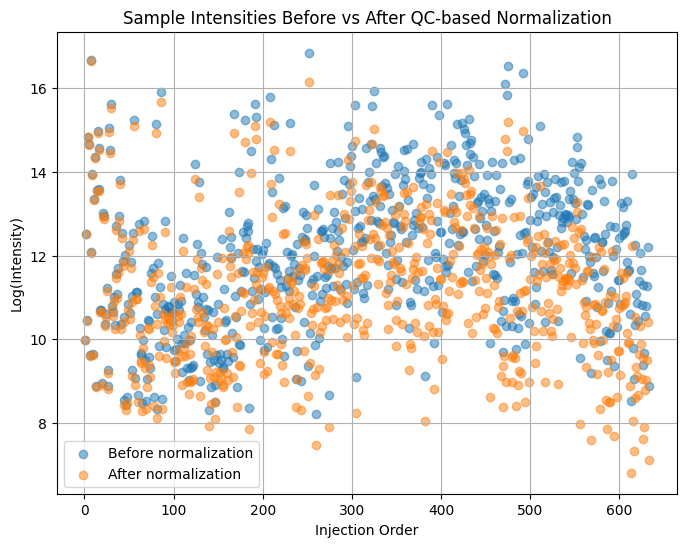

Normalized samples saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\normalized_sample_data.csv


In [51]:
# Normalize samples 
intensity_cols_sample = cleaned_samples.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z', 'Injection_order'])
cleaned_samples['Log_Intensity'] = np.log1p(cleaned_samples[intensity_cols_sample].mean(axis=1))
qc_trend = qc_model.predict(cleaned_samples[['Injection_order']])
cleaned_samples['Log_Intensity_Normalized'] = cleaned_samples['Log_Intensity'] - (qc_trend - qc_model.intercept_)
cleaned_samples['Intensity_Normalized'] = np.expm1(cleaned_samples['Log_Intensity_Normalized'])

# Plot before vs after normalization 
plt.figure(figsize=(8,6))
plt.scatter(cleaned_samples['Injection_order'], cleaned_samples['Log_Intensity'], label='Before normalization', alpha=0.5)
plt.scatter(cleaned_samples['Injection_order'], cleaned_samples['Log_Intensity_Normalized'], label='After normalization', alpha=0.5)
plt.xlabel('Injection Order')
plt.ylabel('Log(Intensity)')
plt.title('Sample Intensities Before vs After QC-based Normalization')
plt.legend()
plt.grid(True)
plt.show()

# Save normalized samples
out_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\normalized_sample_data.csv"
cleaned_samples.to_csv(out_path, index=False)
print(f"Normalized samples saved to: {out_path}")


This means the drift correction worked.

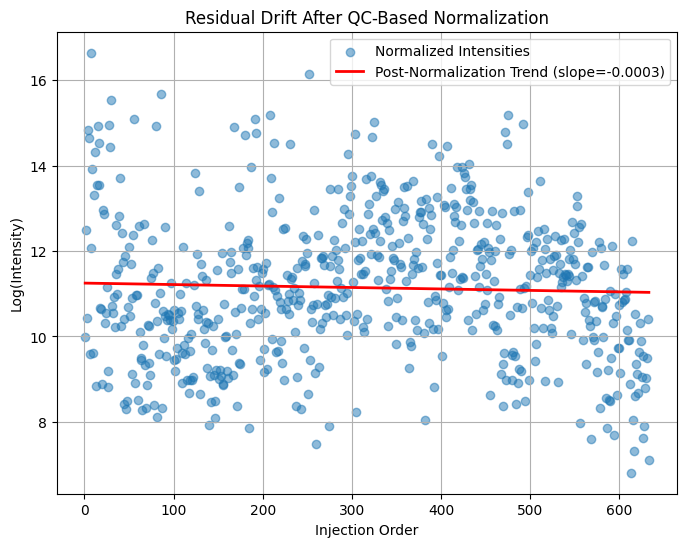

Post-normalization regression slope: -0.000343


In [52]:

# Regression on normalized intensities
X_post = cleaned_samples[['Injection_order']].values
y_post = cleaned_samples['Log_Intensity_Normalized'].values
model_post = LinearRegression().fit(X_post, y_post)
slope_post = model_post.coef_[0]
intercept_post = model_post.intercept_

plt.figure(figsize=(8,6))
plt.scatter(cleaned_samples['Injection_order'], cleaned_samples['Log_Intensity_Normalized'], alpha=0.5, label='Normalized Intensities')
plt.plot(cleaned_samples['Injection_order'], model_post.predict(X_post), color='red', linewidth=2, label=f'Post-Normalization Trend (slope={slope_post:.4f})')
plt.xlabel('Injection Order')
plt.ylabel('Log(Intensity)')
plt.title('Residual Drift After QC-Based Normalization')
plt.legend()
plt.grid(True)
plt.show()

print(f"Post-normalization regression slope: {slope_post:.6f}")


The red regression line is nearly flat , meaning drift has been effectively removed.

# Outlier Detection 

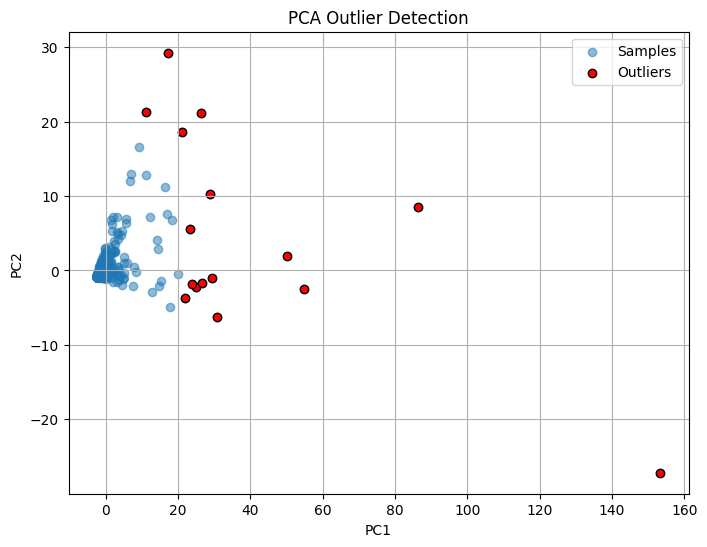

Detected 16 outliers based on PCA distance.


In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Take normalized features
X = corrected_data[intensity_cols_sample]
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

# Compute distance in PC space
z_scores = np.sqrt((pca_scores[:,0]**2) + (pca_scores[:,1]**2))
threshold = np.percentile(z_scores, 97.5)  # Top 2.5% as outliers
outliers = z_scores > threshold

# Plot
plt.figure(figsize=(8,6))
plt.scatter(pca_scores[:,0], pca_scores[:,1], alpha=0.5, label='Samples')
plt.scatter(pca_scores[outliers,0], pca_scores[outliers,1], color='red', label='Outliers', edgecolor='black')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Outlier Detection")
plt.legend()
plt.grid(True)
plt.show()

print(f"Detected {outliers.sum()} outliers based on PCA distance.")


In [54]:


# Select only intensity columns
log_data = np.log1p(cleaned_samples[intensity_cols_sample])  # log-transform

# Compute IQR for each feature
Q1 = log_data.quantile(0.25)
Q3 = log_data.quantile(0.75)
IQR = Q3 - Q1

# Define outlier mask (beyond 1.5×IQR)
outlier_mask = (log_data < (Q1 - 1.5 * IQR)) | (log_data > (Q3 + 1.5 * IQR))

# Replace outliers with NaN
log_data[outlier_mask] = np.nan

# Impute NaN with median of each feature
log_data = log_data.apply(lambda x: x.fillna(x.median()), axis=0)

# Back-transform to original scale
cleaned_samples[intensity_cols_sample] = np.expm1(log_data)

# Save cleaned dataset
out_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\normalized_peak_outlier_imputed.csv"
cleaned_samples.to_csv(out_path, index=False)
print(f"Outlier-cleaned & imputed dataset saved to: {out_path}")


Outlier-cleaned & imputed dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\normalized_peak_outlier_imputed.csv


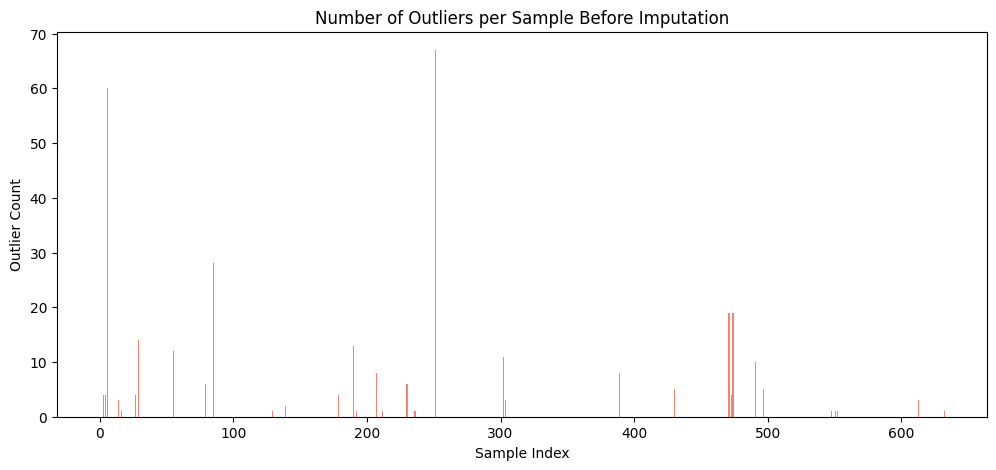

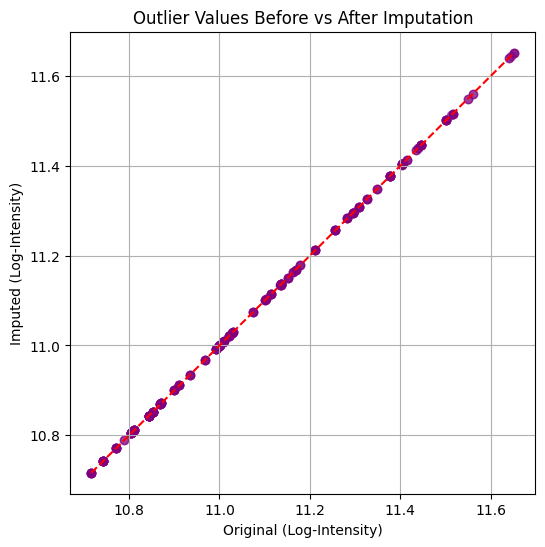

In [55]:
import matplotlib.pyplot as plt

# Count outliers per sample
outliers_per_sample = outlier_mask.sum(axis=1)
plt.figure(figsize=(12,5))
plt.bar(range(len(outliers_per_sample)), outliers_per_sample, color='salmon')
plt.title('Number of Outliers per Sample Before Imputation')
plt.xlabel('Sample Index')
plt.ylabel('Outlier Count')
plt.show()

# Value shift for outliers only 
outlier_indices = np.where(outlier_mask)
original_outliers = log_data.values[outlier_indices]
log_data_imputed = log_data.copy()

# Apply median imputation again (if needed)
for col in log_data.columns:
    median_val = log_data[col].median()
    log_data_imputed.loc[outlier_mask[col], col] = median_val

imputed_outliers = log_data_imputed.values[outlier_indices]  # assuming this is your post-imputation data

plt.figure(figsize=(6,6))
plt.scatter(original_outliers, imputed_outliers, alpha=0.5, color='purple')
plt.plot([min(original_outliers), max(original_outliers)], 
         [min(original_outliers), max(original_outliers)], 'r--')
plt.title('Outlier Values Before vs After Imputation')
plt.xlabel('Original (Log-Intensity)')
plt.ylabel('Imputed (Log-Intensity)')
plt.grid(True)
plt.show()
